In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

Load Dataset

In [11]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

Preprocess Data

In [12]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

Model 1: Neural Network with Relu

In [13]:
model_relu = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_relu.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_relu = model_relu.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8649 - loss: 0.4572 - val_accuracy: 0.9589 - val_loss: 0.1379
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9660 - loss: 0.1146 - val_accuracy: 0.9688 - val_loss: 0.1056
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9774 - loss: 0.0740 - val_accuracy: 0.9695 - val_loss: 0.1015
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9842 - loss: 0.0505 - val_accuracy: 0.9753 - val_loss: 0.0874
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9868 - loss: 0.0398 - val_accuracy: 0.9715 - val_loss: 0.1018
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9907 - loss: 0.0305 - val_accuracy: 0.9722 - val_loss: 0.1031
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9905 - loss: 0.0291 - val_accuracy: 0.9725 - val_loss: 0.1107
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9929 - loss: 0.0204 -

Model 2: Neural Network with Sigmoid

In [14]:
model_sigmoid = keras.Sequential([
    layers.Dense(128, activation='sigmoid', input_shape=(784,)),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(10, activation='softmax')
])

model_sigmoid.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sigmoid = model_sigmoid.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7610 - loss: 0.9527 - val_accuracy: 0.9333 - val_loss: 0.2328
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9373 - loss: 0.2169 - val_accuracy: 0.9524 - val_loss: 0.1711
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9543 - loss: 0.1544 - val_accuracy: 0.9609 - val_loss: 0.1374
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9670 - loss: 0.1126 - val_accuracy: 0.9653 - val_loss: 0.1187
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9751 - loss: 0.0860 - val_accuracy: 0.9696 - val_loss: 0.1037
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9802 - loss: 0.0697 - val_accuracy: 0.9706 - val_loss: 0.1017
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9835 - loss: 0.0556 - val_accuracy: 0.9674 - val_loss: 0.1051
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9873 - loss: 0.0447 -

Evaluate both Models


In [15]:
relu_test = model_relu.evaluate(x_test, y_test)
sigmoid_test = model_sigmoid.evaluate(x_test, y_test)

print("ReLU Test Accuracy:", relu_test[1])
print("Sigmoid Test Accuracy:", sigmoid_test[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9720 - loss: 0.1169
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9722 - loss: 0.0932
ReLU Test Accuracy: 0.9781000018119812
Sigmoid Test Accuracy: 0.9753999710083008


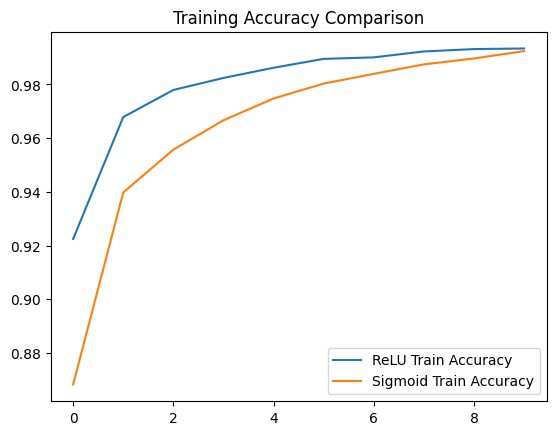

In [16]:
plt.plot(history_relu.history['accuracy'], label='ReLU Train Accuracy')
plt.plot(history_sigmoid.history['accuracy'], label='Sigmoid Train Accuracy')
plt.legend()
plt.title("Training Accuracy Comparison")
plt.show()


Loss Comparison Graph

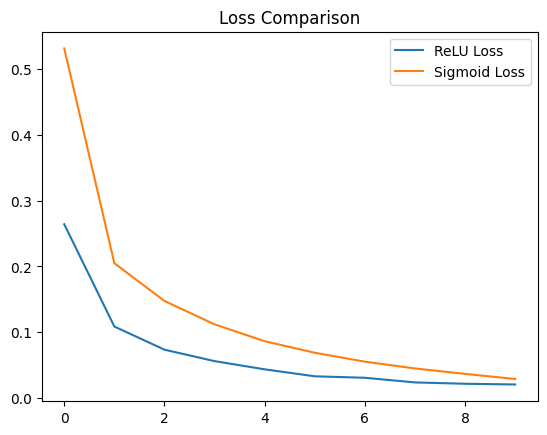

In [17]:
plt.plot(history_relu.history['loss'], label='ReLU Loss')
plt.plot(history_sigmoid.history['loss'], label='Sigmoid Loss')
plt.legend()
plt.title("Loss Comparison")
plt.show()